# Project 2 — Part II (a): the SEIRD model for three real diseases

The stochastic **SEIRD** model is imported from the local library
[`sir_model.py`](sir_model.py) (`simulate_seird`): the same refined chain-binomial scheme
used elsewhere in the project, but the two compartments with several exits, $E$ and $I$,
are sampled from a **Multinomial** of their current count (Algorithm *Stochastic SEIRD
simulation*). This notebook only sets up the experiments and draws the figures.

**What we do.** We run the algorithm for three diseases whose parameters are taken from
*Appendix 2* — **rubella**, **measles** and **smallpox** — and look at how the
compartment counts $S, E, I, R, D$ evolve. The appendix gives, for each disease, a mean
incubation (latency) period, a mean infectious period, a basic reproduction number $R_0$
and a case-fatality ratio (CFR). These map onto the model rates as

$$a=\frac{1}{\text{incubation}},\qquad
\gamma_I+\mu_I=\frac{1}{\text{infectious}},\qquad
\mu_I=\frac{\text{CFR}}{\text{infectious}},\qquad
\beta_I=\frac{R_0}{\text{infectious}} ,$$

the last because, with no presymptomatic transmission, $R_0=\beta_I/(\gamma_I+\mu_I)$.
The appendix gives no information on the exposed-state transmission or removal, so we set
$\beta_E=\gamma_E=\mu_E=0$ (exposed individuals only progress to infectious).

**Initial conditions.** For each disease we use **two initial conditions that differ only
in $S(0)$** (the population size): $N=1000$ (so $S(0)=995$) and $N=10\,000$ (so
$S(0)=9\,995$). Both are seeded with $I(0)=5$ introduced infectious cases (and
$E(0)=R(0)=D(0)=0$); five seeds make stochastic fade-out negligible so the figures show
the epidemic itself rather than the fade-out lottery studied in Part I.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
from sir_model import simulate_seird

IMAGES = Path("..") / "Images"
IMAGES.mkdir(exist_ok=True)

# --- Disease data (Appendix 2) ------------------------------------------------
# inc = mean incubation/latency [days], inf = mean infectious period [days],
# R0  = basic reproduction number, cfr = case-fatality ratio, T = horizon [days].
DISEASES = {
    "Rubella":  dict(inc=17.0, inf=14.0, R0=4.0,  cfr=0.00,  T=320),
    "Measles":  dict(inc=11.5, inf=8.0,  R0=15.0, cfr=0.002, T=120),
    "Smallpox": dict(inc=13.0, inf=14.0, R0=6.0,  cfr=0.30,  T=220),
}

def seird_rates(d):
    """Map the appendix quantities to SEIRD rates (beta_E = gamma_E = mu_E = 0)."""
    out = 1.0 / d["inf"]                       # = gamma_I + mu_I
    return dict(a=1.0 / d["inc"],
                gamma_I=(1.0 - d["cfr"]) * out,
                mu_I=d["cfr"] * out,
                beta_I=d["R0"] * out,
                beta_E=0.0)

# Two initial conditions per disease: same seed, differ only in S(0) = N - I0.
POP_SIZES = [1000, 10000]
I0, E0 = 5, 0
DT, SEED = 0.25, 1

## Derived rates

The table below shows the SEIRD rates obtained from the appendix data, for transparency.
Note that $\beta_I$ grows with $R_0$, so measles ($R_0=15$) has by far the largest force
of infection.

In [2]:
print(f"{'disease':9s} {'a=1/inc':>9s} {'gamma_I':>9s} {'mu_I':>9s} {'beta_I':>9s} {'R0':>6s}")
print("-" * 56)
for name, d in DISEASES.items():
    r = seird_rates(d)
    print(f"{name:9s} {r['a']:9.4f} {r['gamma_I']:9.4f} {r['mu_I']:9.4f} {r['beta_I']:9.4f} {d['R0']:6.1f}")

disease     a=1/inc   gamma_I      mu_I    beta_I     R0
--------------------------------------------------------
Rubella      0.0588    0.0714    0.0000    0.2857    4.0
Measles      0.0870    0.1247    0.0003    1.8750   15.0
Smallpox     0.0769    0.0500    0.0214    0.4286    6.0


## One figure per disease

For each disease we draw a single figure with two panels — the two initial conditions
$S(0)$ — and on each panel the trajectories of all five compartments $S, E, I, R, D$.
A short numeric summary (peak $I$, peak $E$, final size, deaths) is printed alongside.

Rubella   N=  1000  peak I=   180 (t= 85.0 d)  peak E=   262  final size= 98.5%  deaths=  0.0%
Rubella   N= 10000  peak I=  1809 (t=123.2 d)  peak E=  2422  final size= 98.1%  deaths=  0.0%


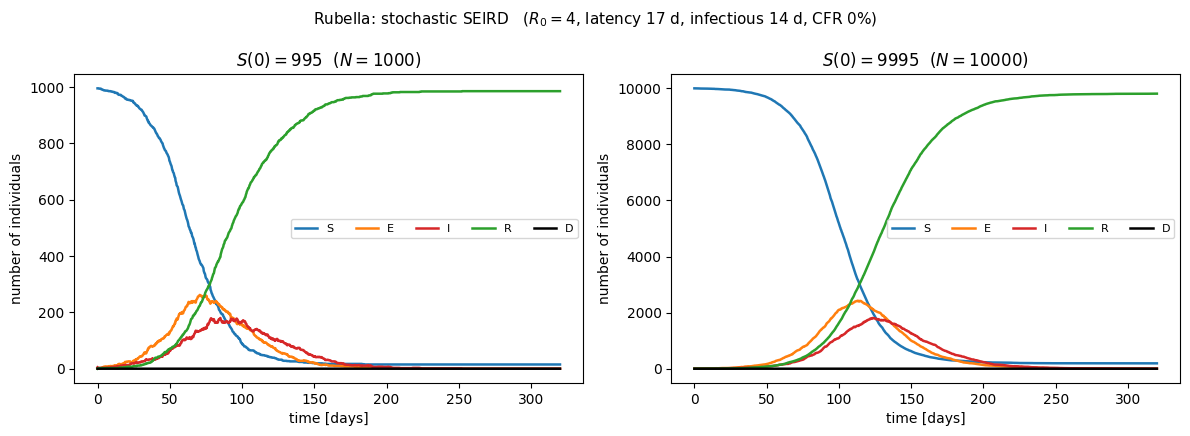

Measles   N=  1000  peak I=   280 (t= 27.5 d)  peak E=   529  final size=100.0%  deaths=  0.2%
Measles   N= 10000  peak I=  2668 (t= 34.2 d)  peak E=  5326  final size=100.0%  deaths=  0.2%


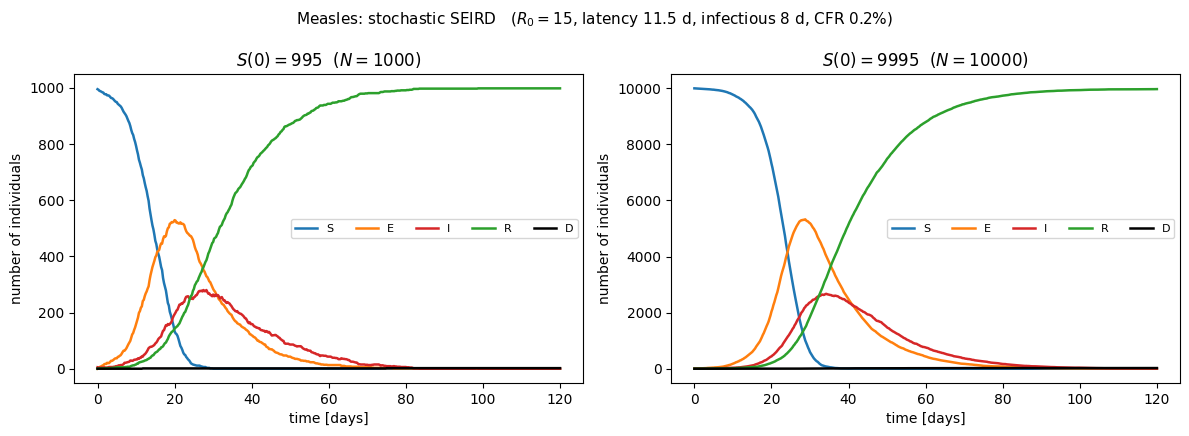

Smallpox  N=  1000  peak I=   291 (t= 71.5 d)  peak E=   315  final size= 99.6%  deaths= 30.8%
Smallpox  N= 10000  peak I=  2684 (t= 88.2 d)  peak E=  3040  final size= 99.8%  deaths= 29.7%


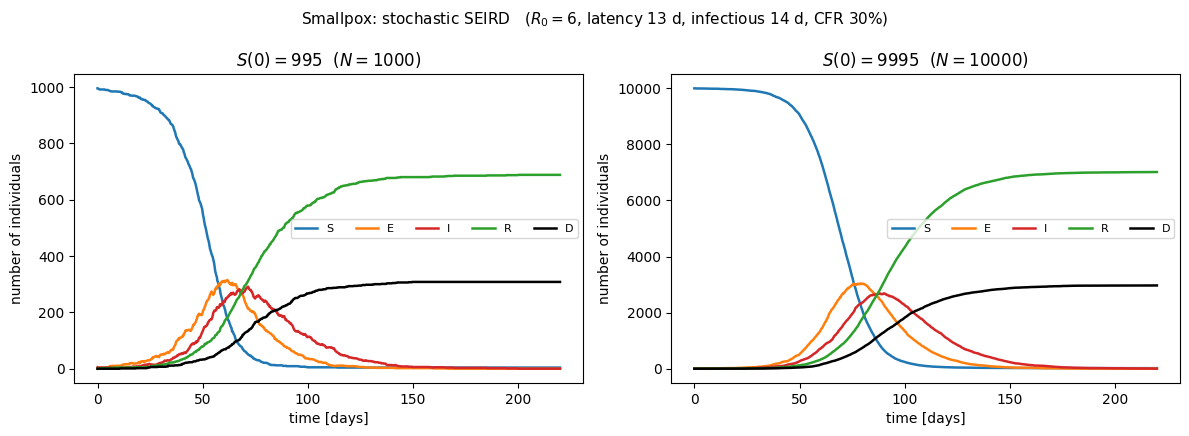

In [3]:
COLORS = {"S": "tab:blue", "E": "tab:orange", "I": "tab:red",
          "R": "tab:green", "D": "black"}

def plot_disease(name, d):
    r = seird_rates(d)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
    for ax, N in zip(axes, POP_SIZES):
        rng = np.random.default_rng(SEED)
        t, S, E, I, R, D = simulate_seird(
            N, r["beta_I"], r["beta_E"], r["a"], r["gamma_I"], r["mu_I"],
            I0=I0, E0=E0, T=d["T"], dt=DT, rng=rng)
        for lab, y in zip("SEIRD", (S, E, I, R, D)):
            ax.plot(t, y, color=COLORS[lab], lw=1.8, label=lab)
        ax.set_title(f"$S(0)={N - I0 - E0}$  ($N={N}$)")
        ax.set_xlabel("time [days]")
        ax.set_ylabel("number of individuals")
        ax.legend(ncol=5, fontsize=8, loc="center right")
        print(f"{name:9s} N={N:6d}  peak I={I.max():6.0f} (t={t[I.argmax()]:5.1f} d)  "
              f"peak E={E.max():6.0f}  final size={100*(N-S[-1])/N:5.1f}%  "
              f"deaths={100*D[-1]/N:5.1f}%")
    fig.suptitle(f"{name}: stochastic SEIRD   "
                 f"($R_0={d['R0']:g}$, latency {d['inc']:g} d, infectious {d['inf']:g} d, "
                 f"CFR {100*d['cfr']:g}%)", fontsize=11)
    fig.tight_layout()
    fig.savefig(IMAGES / f"Proj2_PartIIa_{name.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()

for name, d in DISEASES.items():
    plot_disease(name, d)

## What the figures show

* **The exposed compartment delays and reshapes the epidemic.** In every panel $E$
  (orange) rises *before* $I$ (red) and peaks earlier: susceptibles first accumulate in
  $E$ during the latency period $1/a$ and only then feed $I$. Because the diseases spend a
  comparable or longer time in $E$ than in $I$ and have $R_0\gg1$, the **peak of $E$ is
  actually higher than the peak of $I$** (clearest for measles, where the latency period
  is longer than the infectious period).

* **$R_0$ sets the speed and sharpness, not the final size.** Measles ($R_0=15$) burns
  through the whole population in about a month with a tall, narrow peak; smallpox
  ($R_0=6$) takes ~3 months; rubella ($R_0=4$) is the slowest and flattest. Yet *all three*
  eventually infect ~98–100 % of the population — for $R_0\gg1$ the final size relation
  pushes the attack rate close to one regardless of $R_0$.

* **Mortality is what distinguishes the diseases' outcome.** Rubella and measles end with
  essentially everyone in $R$ (green) and $D\approx0$; smallpox, with a 30 % CFR, ends with
  $D$ (black) at roughly 30 % of the population — about three in ten of those infected die.

* **Larger populations give smoother (more deterministic) trajectories.** The $N=10\,000$
  panels are visibly less jagged than the $N=1000$ panels: relative stochastic fluctuations
  shrink like $1/\sqrt{N}$, while the *shape* of the curves (timing, attack rate, death
  fraction) is essentially identical across the two $S(0)$ — the mean-field behaviour is
  scale-invariant and the noise is the only $N$-dependent feature.